# 실습 14: 잣대가 둘이면 겹치는 데가 보인다
- 상황: 한 방법으로만 짚은 결과를 그대로 믿기는 어렵다
- 목표: 다르게 생긴 방법으로 한 번 더 짚고, 둘이 같이 가리킨 줄을 찾는다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

X = df[sensor_cols]
정답 = (df['result'] == '불량').astype(int)

탐지기 = IsolationForest(contamination=0.05, random_state=42)
고립지목 = 탐지기.fit_predict(X)

이상건수 = (고립지목 == -1).sum()
그중불량 = int(((고립지목 == -1) & (정답 == 1)).sum())

print('이상(-1) 건수:', 이상건수)
print('그중 불량:', 그중불량)

이상(-1) 건수: 79
그중 불량: 12


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 두 번째 잣대

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 이웃과 비교하기 | 국소 이상치 인자 (Local Outlier Factor, LOF) | 내 주변이 얼마나 붐비는지를 보는 방법. 혼자 떨어져 있으면 이상 |
| 이웃 수 | n_neighbors | 몇 명을 이웃으로 볼지. 이것도 사람이 정하는 값 |
| 끝값 | 이상치 (outlier) | 다른 값들보다 유난히 크거나 작은 값. 고립시키기가 잘 잡는 쪽 |
| 무리에서 떨어진 것 | 국소 이상치 (local outlier) | 값 자체는 평범한데 어느 무리에도 안 끼는 줄. 이웃 비교가 잘 잡는 쪽 |
| 겹침 | 교집합 (intersection) | 두 방법이 같이 지목한 줄 |
| 여러 방법을 합쳐 쓰기 | 앙상블 (ensemble) | 한 방법만 믿지 않고 여러 결과를 모아 판단하는 것 |

가운데 칸이 진짜 이름이다. 지난주에 배운 정밀도·재현율처럼 이쪽으로 말해야 통한다.

## Step 2. 이웃과 비교해서 지목하기

In [2]:
# 주변이 얼마나 붐비는지로 이상을 찾는 도구를 불러온다
from sklearn.neighbors import LocalOutlierFactor

# ① 바로 위에서 불러온 도구 이름을 그대로 쓴다
# ② 이웃을 몇 명까지 볼지 정하는 자리
# ③ 몇 %를 이상으로 볼지 정하는 자리 - 앞 실습과 같게 둬야 견줄 수 있다
이웃탐지기 = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# ④ 여기도 정답은 넣지 않는다
이웃지목 = 이웃탐지기.fit_predict(X)

# ⑤ 이 도구도 앞 실습과 같은 약속을 쓴다
이웃이상 = (이웃지목 == -1)

# ⑥ 두 표시가 둘 다 참인 자리만 남기는 기호
# ⑦ 불량을 무엇으로 적어뒀는지
print("이웃 비교 지목:", 이웃이상.sum(), "건")
print("그중 불량:", (이웃이상 & (정답 == 1)).sum(), "건")

이웃 비교 지목: 79 건
그중 불량: 5 건


### 문법 노트 - 두 번째 방법

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ① | `LocalOutlierFactor` | 주변이 얼마나 붐비는지로 이상을 찾는 도구 | 새로 배움 |
| ② | `n_neighbors` | 이웃을 몇 명까지 볼지 정하는 자리 | 새로 배움 |
| ③ | `contamination` | 전체의 몇 %를 이상으로 볼지 | 앞 실습에서 배웠다 |
| ④ | `X` | 센서 값만 담긴 것 | 계속 쓴 이름 |
| ⑤ | `-1` | 이상이라는 표시 (정상은 `1`) | 앞 실습에서 배웠다 |
| ⑥ | `&` | 양쪽이 다 참인 자리만 참 | 앞 실습에서 배웠다 |
| ⑦ | `1` | 불량을 1로 적어둔 그 값 | 계속 쓰는 약속 |

## Step 4. 두 방법을 나란히

In [3]:
전체불량 = int((정답 == 1).sum())

비교표 = pd.DataFrame([
    {
        '방법': '고립시키기 (IsolationForest)',
        '지목 건수': int(이상건수),
        '그중 불량': 그중불량,
        '지목 중 진짜(%)': round(그중불량 / 이상건수 * 100, 1),
        '전체 불량 중 잡은 것(%)': round(그중불량 / 전체불량 * 100, 1),
    },
    {
        '방법': '이웃 비교 (LocalOutlierFactor)',
        '지목 건수': int(이웃이상.sum()),
        '그중 불량': int((이웃이상 & (정답 == 1)).sum()),
        '지목 중 진짜(%)': round(int((이웃이상 & (정답 == 1)).sum()) / 이웃이상.sum() * 100, 1),
        '전체 불량 중 잡은 것(%)': round(int((이웃이상 & (정답 == 1)).sum()) / 전체불량 * 100, 1),
    },
]).set_index('방법')

print('전체 불량률:', round(정답.mean() * 100, 2), '%')
비교표

전체 불량률: 6.64 %


,지목 건수,그중 불량,지목 중 진짜(%),전체 불량 중 잡은 것(%)
방법,,,,
고립시키기 (IsolationForest),79,12,15.2,11.5
이웃 비교 (LocalOutlierFactor),79,5,6.3,4.8


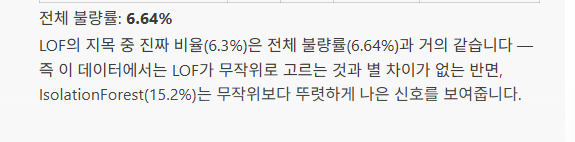

## Step 5. 둘이 같이 짚은 줄

In [4]:
# ⑧ 앞 실습 방식대로 고립시키기 쪽 표시도 만들어 둔다
고립이상 = (고립지목 == -1)

# ⑨ 두 방법이 같이 지목한 줄만 남기는 기호
둘다 = 고립이상 & 이웃이상

# ⑩ 둘 중 하나라도 지목한 줄을 남기는 기호
둘중하나 = 고립이상 | 이웃이상

print("둘 다 지목:", 둘다.sum(), "건 / 그중 불량", (둘다 & (정답 == 1)).sum(), "건")
print("둘 중 하나라도:", 둘중하나.sum(), "건 / 그중 불량", (둘중하나 & (정답 == 1)).sum(), "건")

# ⑪ 참인 자리가 몇 개인지 세는 것
# ⑫ 소수점 몇 자리에서 끊을지
print("둘 다 지목한 것의 적중률:",
      round((둘다 & (정답 == 1)).sum() / 둘다.sum() * 100, 1), "%")

둘 다 지목: 9 건 / 그중 불량 2 건
둘 중 하나라도: 149 건 / 그중 불량 15 건
둘 다 지목한 것의 적중률: 22.2 %


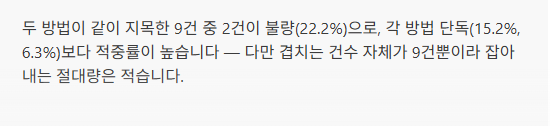

### 문법 노트 - 두 목록 겹치기

두 표시를 묶는 기호가 둘이다.

    둘 다 참인 자리만    ->  &
    한쪽만 참이어도      ->  |

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑧ | `-1` | 이 도구들이 쓰는 이상 표시 | 앞 실습에서 배웠다 |
| ⑨ | `&` | 양쪽이 다 참인 자리만 참 | 앞 실습에서 배웠다 |
| ⑩ | `\|` | 한쪽이라도 참이면 참 | 새로 배움 |
| ⑪ | `.sum()` | 참인 자리의 개수를 센다 | 계속 쓴 것 |
| ⑫ | `1` | 소수점 첫째 자리까지 남긴다 | 첫날부터 쓴 `round` |

## Step 6. 오늘 알게 된 것

| 방법 | 지목 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 고립시키기 | [79] | [12] | [15.2%] |
| 이웃 비교 | [79] | [5] | [6.3%] |
| 둘 다 지목 | [9] | [2] | [22.2%] |

- 겹친 목록이 더 진한가 : [22.2%로 고립시키기(15.2%)보다도 높다. 혼자서는 6.3%였던 이웃 비교가 겹치니 값을 했다]
- 겹치면 무엇을 잃나 : [열어볼 건수가 79건에서 [9]건으로 줄었다. 잡은 불량도 2건뿐이라 대부분 놓친다]
- 이 목록을 어디에 쓰나 : [먼저 열어볼 순서. 여기서도 판정이 아니라 후보다]

---
## 직접 해보기 (도전) - 지난주 모델도 같은 줄을 짚었나

- 상황: 답을 보고 배운 지난주 모델과, 답 없이 짚은 오늘 목록이 같은 줄을 가리켰을까
- 할 일: 지난주 모델의 불량 예측과 오늘 겹침 목록을 다시 겹쳐본다
- 결과물: 세 줄짜리 표 1개 + 한 줄 메모

### 1단. 지난주 모델과 겹쳐 보기

In [5]:
# 지난주에 쓴 모델 그대로: 표준화 + LogisticRegression(max_iter=1000, class_weight="balanced")
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

로지스틱모델 = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, class_weight="balanced"))

# 오늘은 시험용을 따로 떼지 않고, 전체 데이터에 학습시키고 전체를 예측한다
로지스틱모델.fit(X, 정답)
로지스틱예측 = 로지스틱모델.predict(X)

로지스틱이상 = (로지스틱예측 == 1)

# 지난주 모델과 오늘 겹침(둘 다 지목)이 같이 가리킨 줄
로지스틱과겹침 = 로지스틱이상 & 둘다


def 채점(이름, 표시):
    지목건수 = int(표시.sum())
    그중불량 = int((표시 & (정답 == 1)).sum())
    return {
        '목록': 이름,
        '지목 건수': 지목건수,
        '그중 불량': 그중불량,
        '지목 중 진짜(%)': round(그중불량 / 지목건수 * 100, 1) if 지목건수 > 0 else 0.0,
    }


겹침비교표 = pd.DataFrame([
    채점('지난주 모델 (로지스틱 회귀)', 로지스틱이상),
    채점('오늘 겹침 (둘 다 지목)', 둘다),
    채점('지난주 모델 ∩ 오늘 겹침', 로지스틱과겹침),
]).set_index('목록')

겹침비교표

,지목 건수,그중 불량,지목 중 진짜(%)
목록,,,
지난주 모델 (로지스틱 회귀),417,78,18.7
오늘 겹침 (둘 다 지목),9,2,22.2
지난주 모델 ∩ 오늘 겹침,6,2,33.3


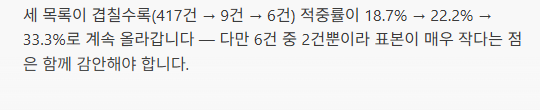

### 답을 본 쪽과 안 본 쪽

| 무엇 | 지목 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 지난주 모델 (답을 보고 배움) | [417] | [78] | [18.7%] |
| 오늘 겹침 목록 (답 안 봄) | [9] | [2] | [22.2%] |
| 셋이 다 가리킨 줄 | [6] | [2] | [33.3%] |

- 알게 된 것 : [근거가 늘수록 진해진다. 22.2% → 33.3%. 대신 9건이 6건으로 줄었다]

### 2단. 이웃 수를 바꿔보기

In [6]:
# n_neighbors만 바꿔가며 같은 방식으로 지목하고, 고립시키기(고립이상)와 겹치는 건수도 함께 본다
결과_이웃 = []
for 이웃수 in [5, 20, 50, 100]:
    이웃탐지기_n = LocalOutlierFactor(n_neighbors=이웃수, contamination=0.05)
    이웃지목_n = 이웃탐지기_n.fit_predict(X)
    이웃이상_n = (이웃지목_n == -1)

    지목건수_n = int(이웃이상_n.sum())
    그중불량_n = int((이웃이상_n & (정답 == 1)).sum())
    고립과겹침_n = int((이웃이상_n & 고립이상).sum())

    결과_이웃.append({
        '이웃 수': 이웃수,
        '지목 건수': 지목건수_n,
        '그중 불량': 그중불량_n,
        '지목 중 진짜(%)': round(그중불량_n / 지목건수_n * 100, 1) if 지목건수_n > 0 else 0.0,
        '고립시키기와 겹친 건수': 고립과겹침_n,
    })

이웃수비교표 = pd.DataFrame(결과_이웃).set_index('이웃 수')
이웃수비교표

,지목 건수,그중 불량,지목 중 진짜(%),고립시키기와 겹친 건수
이웃 수,,,,
5,79,5,6.3,14
20,79,5,6.3,9
50,79,11,13.9,42
100,79,11,13.9,43


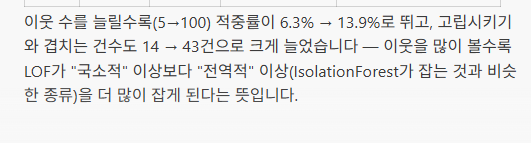

### 이웃 수를 바꾸면

(강사 정제본 실측: 5는 14건, 20은 9건, 50은 42건, 100은 43건이 겹쳤다)

| 이웃 수 | 그중 불량 | 지목 중 진짜 | 고립시키기와 겹친 건수 |
|---|---|---|---|
| 5 | [5] | [6.3%] | [14] |
| 20 | [5] | [6.3%] | [9] |
| 50 | [11] | [13.9%] | [42] |
| 100 | [11] | [13.9%] | [43] |

- 알게 된 것 : [이웃을 50명까지 보게 하니 적중이 6.3%에서 13.9%로 두 배가 됐다. 겹친 건수도 9건에서 42건으로 뛰었다]

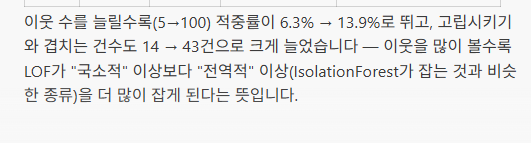